# Notebook 5: Risk Assessment Module
### NIFTY-50 Investment Intelligence — Mandatory Task C

In [21]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import get_close_price_matrix, load_stock, get_sector_map
from src.portfolio import get_price_data, load_portfolios
from src.risk import (compute_stock_metrics, compute_portfolio_metrics,
                      stress_test_portfolio, build_risk_table,
                      classify_risk, compute_rolling_risk, compute_beta)

os.makedirs('../report', exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print("Imports OK")

Imports OK


## 1. Universe Risk Scorecard

In [22]:
prices = get_price_data('2015-01-01')
print("Computing risk metrics for all stocks (takes ~30 seconds)...")
risk_df = build_risk_table(prices, start_date='2015-01-01')

print(f"Stocks analysed: {len(risk_df)}")
print()
display_cols = ['symbol','sector','cagr_pct','annual_volatility_pct',
                'sharpe_ratio','sortino_ratio','max_drawdown_pct',
                'var_95_daily_pct','beta','risk_level']
print(risk_df[display_cols].to_string(index=False))

# Save for Streamlit
risk_df.to_csv('../models/risk_scorecard.csv', index=False)
print("\nRisk scorecard saved.")

Computing risk metrics for all stocks (takes ~30 seconds)...
Stocks analysed: 48

    symbol                   sector  cagr_pct  annual_volatility_pct  sharpe_ratio  sortino_ratio  max_drawdown_pct  var_95_daily_pct  beta risk_level
BAJAJFINSV       FINANCIAL SERVICES     40.46                  36.40         0.974          1.332            -58.59            -3.106 1.040       HIGH
HINDUNILVR           CONSUMER GOODS     19.60                  23.76         0.614          1.036            -21.32            -2.082 0.503     MEDIUM
ASIANPAINT           CONSUMER GOODS     21.26                  26.60         0.611          0.912            -28.86            -2.390 0.685       HIGH
     TITAN           CONSUMER GOODS     24.14                  32.85         0.583          0.875            -41.73            -2.841 0.727       HIGH
  SHREECEM CEMENT & CEMENT PRODUCTS     18.81                  31.29         0.441          0.703            -36.90            -2.894 0.988       HIGH
 NESTLEIND  

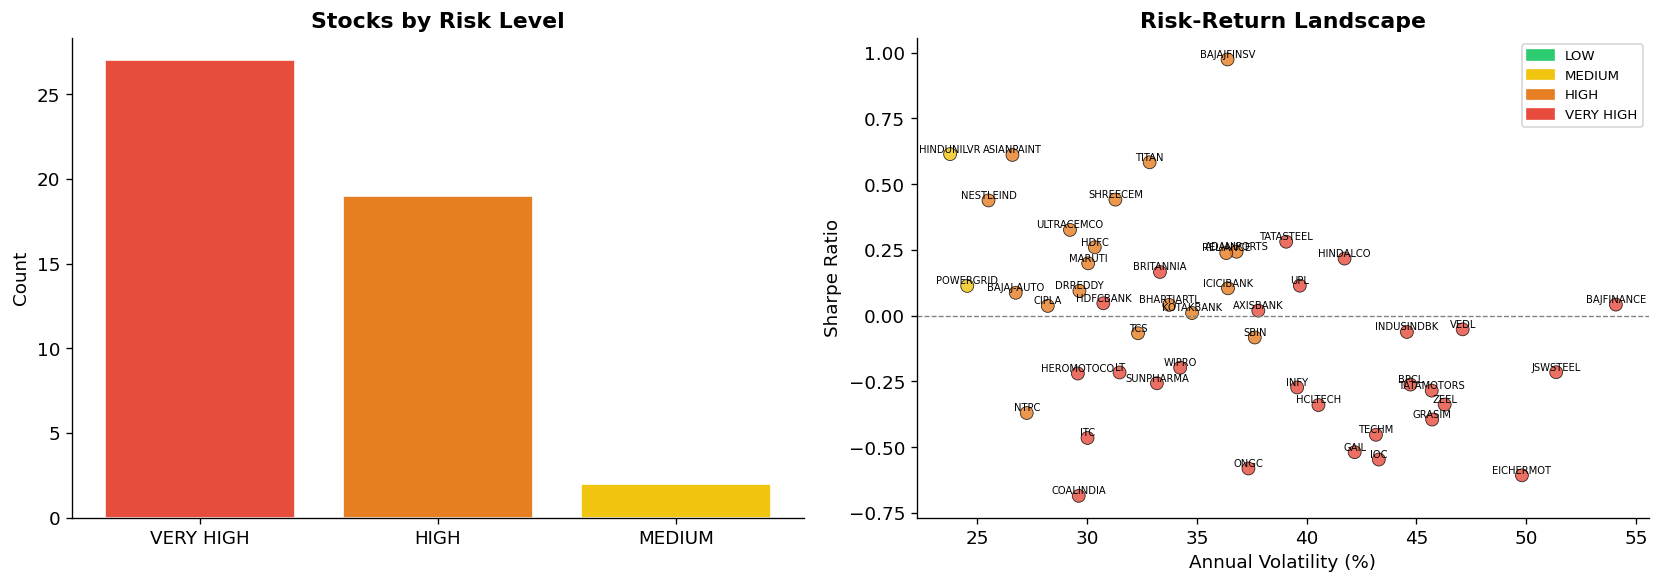

In [23]:
# Risk level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by risk level
risk_counts = risk_df['risk_level'].value_counts()
colors_rl = {'LOW': '#2ecc71', 'MEDIUM': '#f1c40f', 'HIGH': '#e67e22', 'VERY HIGH': '#e74c3c'}
bar_colors = [colors_rl.get(r, 'gray') for r in risk_counts.index]
axes[0].bar(risk_counts.index, risk_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title("Stocks by Risk Level", fontweight='bold')
axes[0].set_ylabel("Count")

# Sharpe vs Volatility scatter
scatter_colors = [colors_rl.get(r, 'gray') for r in risk_df['risk_level']]
axes[1].scatter(risk_df['annual_volatility_pct'], risk_df['sharpe_ratio'],
                c=scatter_colors, alpha=0.8, s=60, edgecolors='black', linewidth=0.5)
for _, row in risk_df.iterrows():
    axes[1].annotate(row['symbol'], (row['annual_volatility_pct'], row['sharpe_ratio']),
                     fontsize=6, ha='center', va='bottom')
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_xlabel("Annual Volatility (%)")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title("Risk-Return Landscape", fontweight='bold')

patches = [mpatches.Patch(color=c, label=l) for l, c in colors_rl.items()]
axes[1].legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig('../report/risk_landscape.png', bbox_inches='tight')
plt.show()

## 2. VaR & CVaR Analysis

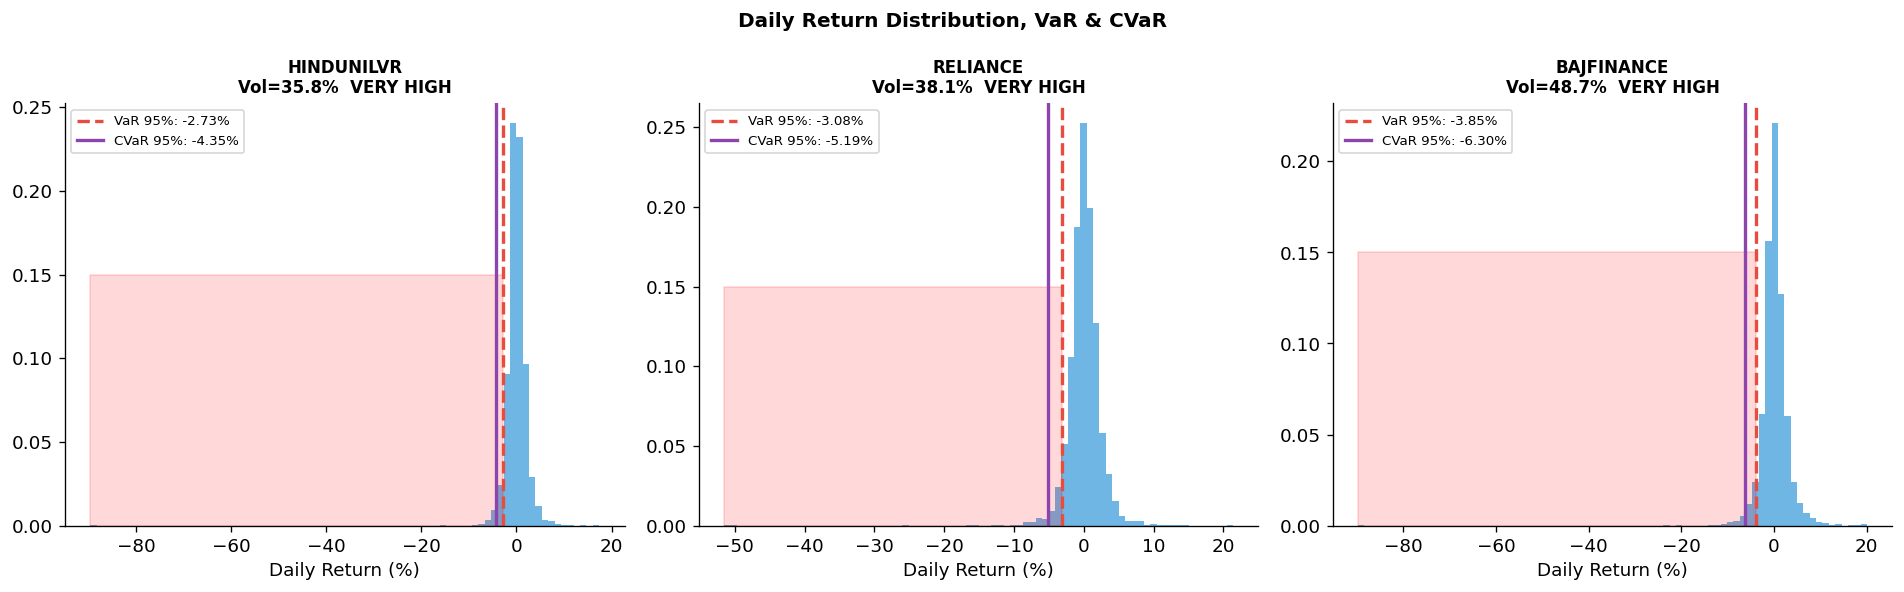

In [24]:
import matplotlib.patches as mpatches

# Illustrate VaR for 3 stocks: low / medium / high risk
sample_stocks = [
    risk_df.sort_values('annual_volatility_pct').iloc[0]['symbol'],   # lowest vol
    risk_df.sort_values('annual_volatility_pct').iloc[len(risk_df)//2]['symbol'], # mid
    risk_df.sort_values('annual_volatility_pct').iloc[-1]['symbol'],  # highest vol
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, sym in zip(axes, sample_stocks):
    df_s = load_stock(sym)
    rets = df_s['Close'].pct_change().dropna() * 100
    
    ax.hist(rets, bins=80, color='#3498db', alpha=0.7, density=True, edgecolor='none')
    
    var95 = np.percentile(rets, 5)
    cvar95 = rets[rets <= var95].mean()
    
    ax.axvline(var95,  color='#e74c3c',  lw=2, linestyle='--', label=f'VaR 95%: {var95:.2f}%')
    ax.axvline(cvar95, color='#8e44ad',  lw=2, linestyle='-',  label=f'CVaR 95%: {cvar95:.2f}%')
    ax.fill_between([rets.min(), var95], 0, 0.15, alpha=0.15, color='red')
    
    m = compute_stock_metrics(df_s.set_index('Date')['Close'], sym)
    ax.set_title(f"{sym}\nVol={m['annual_volatility_pct']:.1f}%  {classify_risk(m)}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel("Daily Return (%)")
    ax.legend(fontsize=8)

plt.suptitle("Daily Return Distribution, VaR & CVaR", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/var_cvar.png', bbox_inches='tight')
plt.show()

## 3. Portfolio Risk Comparison

In [25]:
portfolios = load_portfolios()
profile_names = ['conservative', 'balanced', 'aggressive', 'risk_parity', 'equal_weight']

port_metrics = {}
for name in profile_names:
    p = portfolios[name]
    print(f"Computing risk for {p['label']}...")
    pm = compute_portfolio_metrics(p['weights'], prices)
    port_metrics[name] = pm

print()
print(f"{'Portfolio':<22} {'CAGR%':>7} {'Vol%':>7} {'Sharpe':>8} {'Sortino':>9} {'MaxDD%':>8} {'VaR95%':>8}")
print("-" * 75)
for name in profile_names:
    pm = port_metrics[name]
    label = portfolios[name]['label']
    print(f"{label:<22} {pm['cagr_pct']:>7.2f} {pm['annual_volatility_pct']:>7.2f} "
          f"{pm['sharpe_ratio']:>8.3f} {pm['sortino_ratio']:>9.3f} "
          f"{pm['max_drawdown_pct']:>8.2f} {pm['var_95_daily_pct']:>8.3f}")

Computing risk for Conservative Investor...
Computing risk for Balanced Investor...
Computing risk for Aggressive Investor...
Computing risk for Risk Parity...
Computing risk for Equal Weight...

Portfolio                CAGR%    Vol%   Sharpe   Sortino   MaxDD%   VaR95%
---------------------------------------------------------------------------
Conservative Investor     8.72   14.30    0.260     0.335   -25.09   -1.242
Balanced Investor        25.04   18.50    1.084     1.444   -30.92   -1.574
Aggressive Investor      30.46   22.66    1.124     1.500   -36.77   -2.004
Risk Parity               9.54   17.82    0.255     0.301   -39.19   -1.628
Equal Weight              9.21   18.54    0.227     0.267   -41.77   -1.693


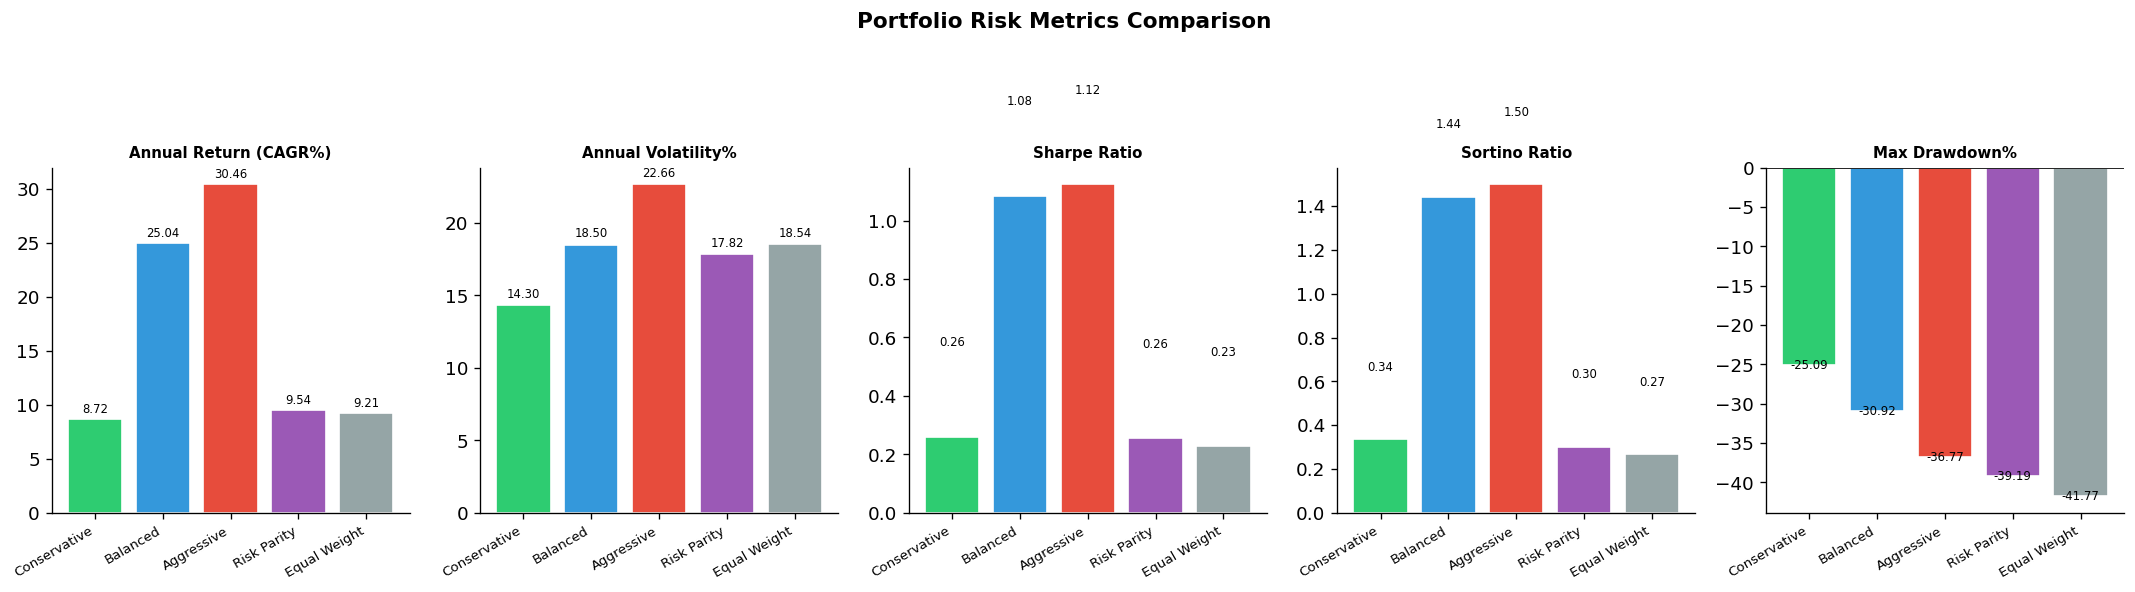

In [26]:
# Risk comparison radar / bar charts
metrics_to_compare = {
    'Annual Return (CAGR%)': 'cagr_pct',
    'Annual Volatility%':    'annual_volatility_pct',
    'Sharpe Ratio':          'sharpe_ratio',
    'Sortino Ratio':         'sortino_ratio',
    'Max Drawdown%':         'max_drawdown_pct',
}

fig, axes = plt.subplots(1, len(metrics_to_compare), figsize=(18, 5))
port_colors = {
    'conservative': '#2ecc71', 'balanced': '#3498db', 'aggressive': '#e74c3c',
    'risk_parity': '#9b59b6', 'equal_weight': '#95a5a6'
}
port_labels = {name: portfolios[name]['label'].replace(' Investor','') for name in profile_names}

for ax, (metric_label, metric_key) in zip(axes, metrics_to_compare.items()):
    vals   = [port_metrics[n][metric_key] for n in profile_names]
    labels = [port_labels[n] for n in profile_names]
    colors = [port_colors[n] for n in profile_names]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white')
    ax.set_title(metric_label, fontsize=9, fontweight='bold')
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    if metric_key == 'max_drawdown_pct':
        ax.axhline(0, color='black', lw=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if val >= 0 else -0.8),
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle("Portfolio Risk Metrics Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/portfolio_risk_comparison.png', bbox_inches='tight')
plt.show()

## 4. Stress Testing

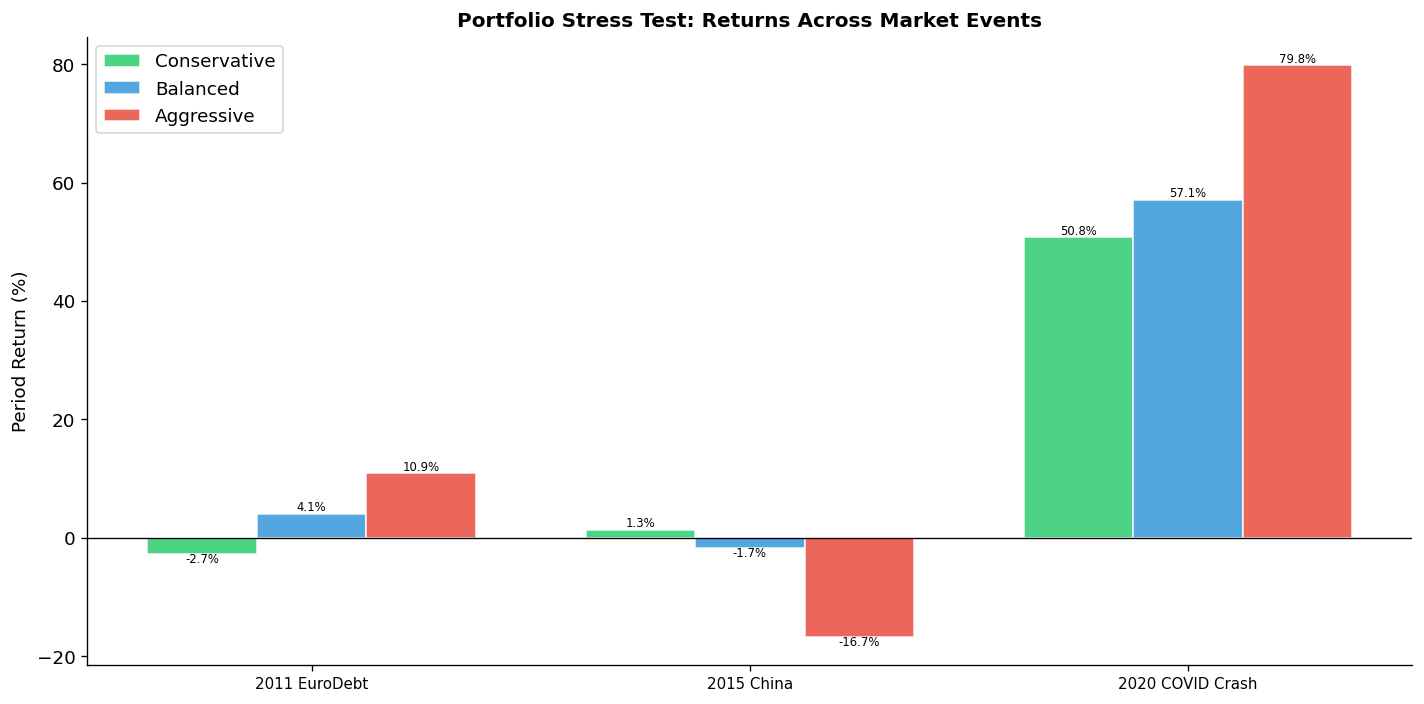

In [27]:
stress_results = {}
for name in ['conservative','balanced','aggressive']:
    p = portfolios[name]
    stress_results[name] = stress_test_portfolio(p['weights'], prices)

# Plot stress test returns
all_periods = list(list(stress_results.values())[0].keys())
valid_periods = [p for p in all_periods
                 if all(stress_results[n][p]['return_pct'] is not None
                        for n in ['conservative','balanced','aggressive'])]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(valid_periods))
width = 0.25
colors3 = ['#2ecc71','#3498db','#e74c3c']
labels3 = ['Conservative','Balanced','Aggressive']

for i, (name, color, label) in enumerate(zip(['conservative','balanced','aggressive'], colors3, labels3)):
    vals = [stress_results[name][p]['return_pct'] for p in valid_periods]
    bars = ax.bar(x + i*width, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        y_pos = val + 0.5 if val >= 0 else val - 1.5
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:.1f}%', ha='center', fontsize=7)

ax.set_xticks(x + width)
period_labels = ['2011 EuroDebt', '2015 China', '2020 COVID Crash', '2020 Recovery']
ax.set_xticklabels(period_labels[:len(valid_periods)], fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel("Period Return (%)")
ax.set_title("Portfolio Stress Test: Returns Across Market Events", fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../report/stress_test.png', bbox_inches='tight')
plt.show()

## 5. Rolling Risk — Balanced Portfolio

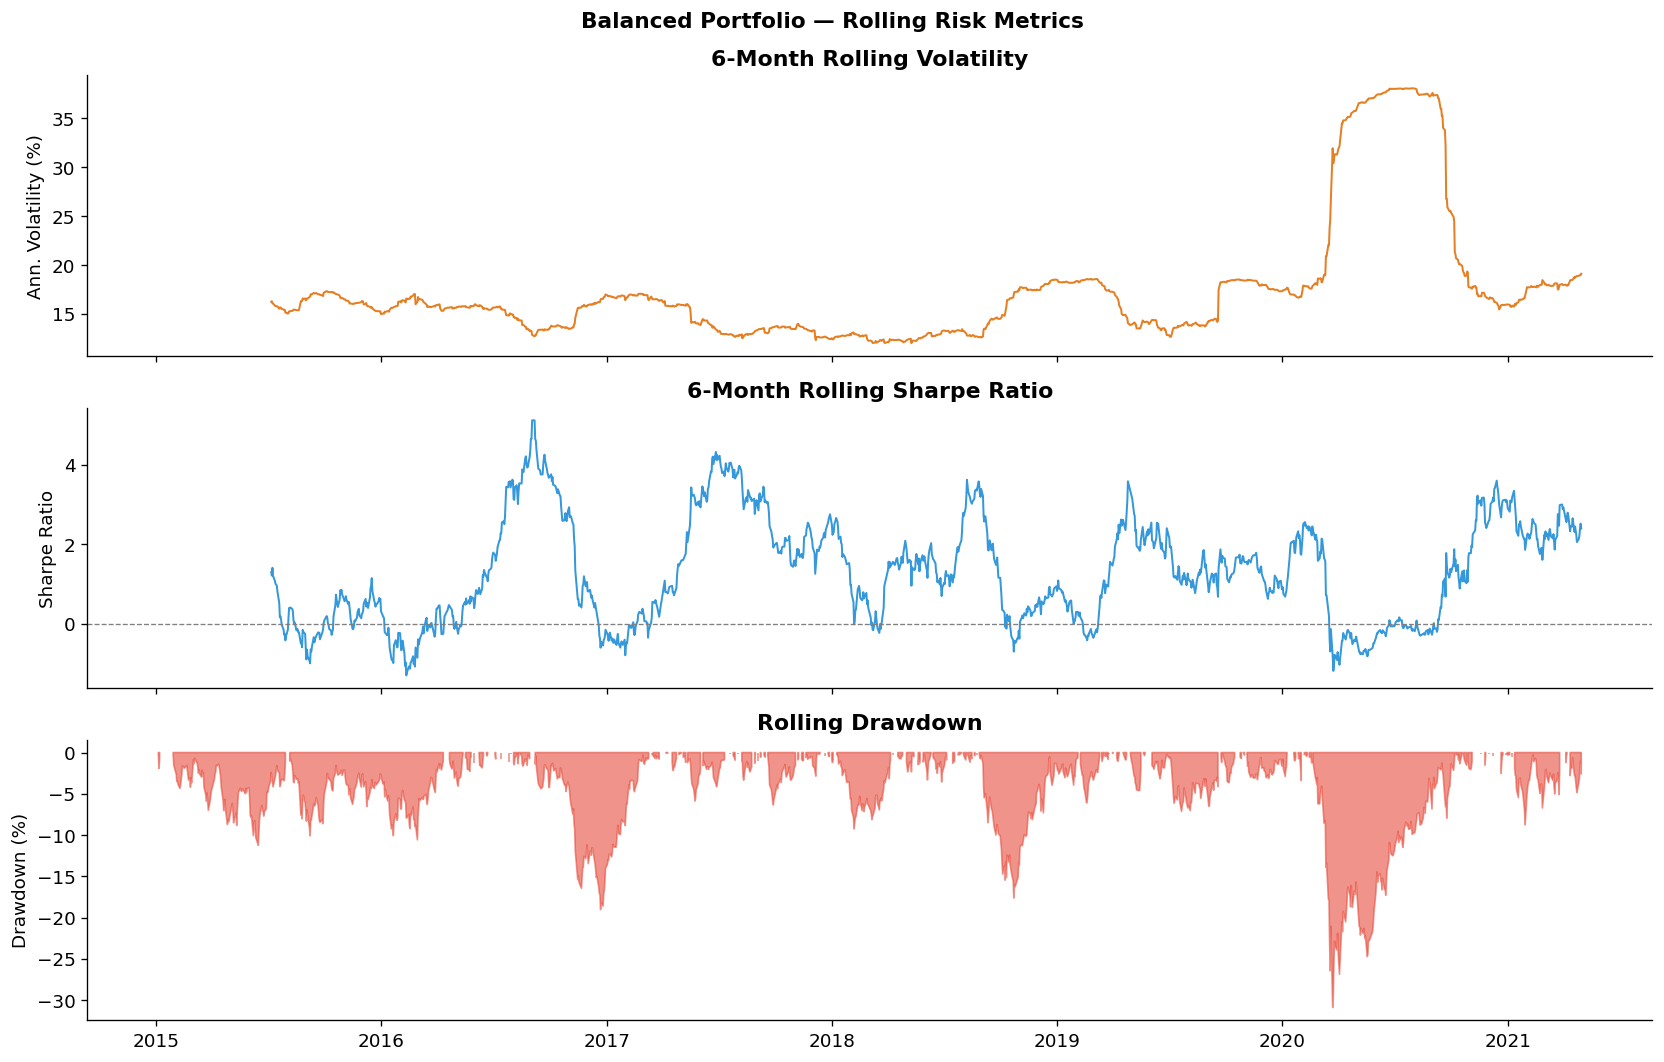

In [28]:
bal_w = portfolios['balanced']['weights']
common = [c for c in bal_w if c in prices.columns]
w = pd.Series({k: bal_w[k] for k in common})
w /= w.sum()
port_ret = (prices[common].pct_change().dropna() * w).sum(axis=1)
port_price = (1 + port_ret).cumprod() * 100

rolling = compute_rolling_risk(port_price, window=126)  # 6-month rolling

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(rolling.index, rolling['Rolling_Vol_pct'], color='#e67e22', lw=1.2)
axes[0].set_ylabel("Ann. Volatility (%)"); axes[0].set_title("6-Month Rolling Volatility", fontweight='bold')

axes[1].plot(rolling.index, rolling['Rolling_Sharpe'], color='#3498db', lw=1.2)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_ylabel("Sharpe Ratio"); axes[1].set_title("6-Month Rolling Sharpe Ratio", fontweight='bold')

axes[2].fill_between(rolling.index, rolling['Rolling_Drawdown'], 0,
                     where=(rolling['Rolling_Drawdown'] < 0), color='#e74c3c', alpha=0.6)
axes[2].set_ylabel("Drawdown (%)"); axes[2].set_title("Rolling Drawdown", fontweight='bold')

plt.suptitle("Balanced Portfolio — Rolling Risk Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/rolling_risk.png', bbox_inches='tight')
plt.show()

## 6. Risk Contribution Analysis

Effective number of stocks (diversification): 7.2
Herfindahl concentration index: 0.1384


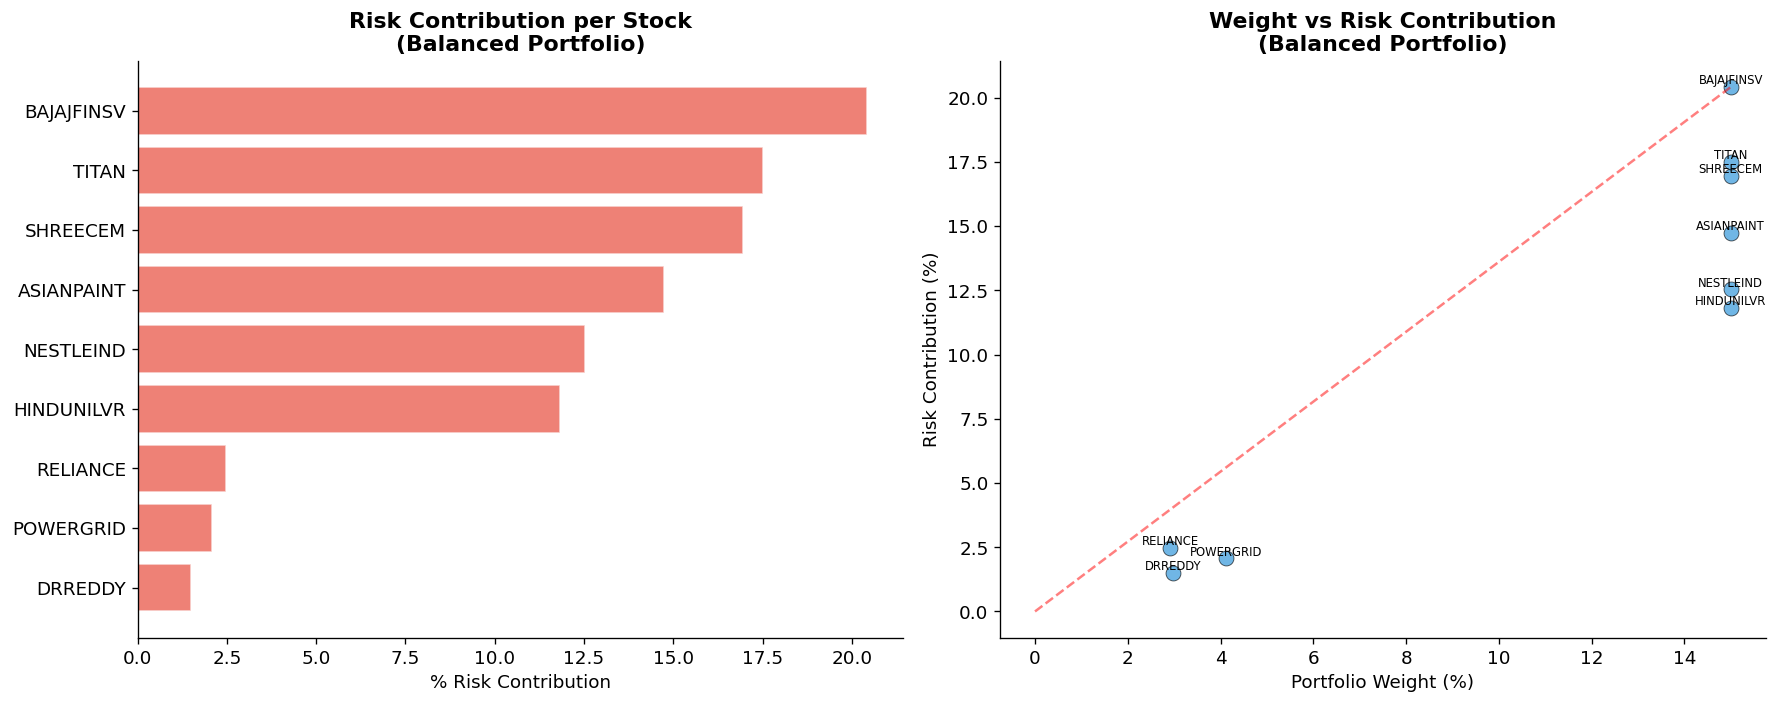

In [29]:
bal_metrics = port_metrics['balanced']
risk_contrib = pd.Series(bal_metrics['risk_contributions']).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Risk contribution bar chart
axes[0].barh(risk_contrib.index[::-1], risk_contrib.values[::-1],
             color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_xlabel("% Risk Contribution")
axes[0].set_title("Risk Contribution per Stock\n(Balanced Portfolio)", fontweight='bold')

# Weight vs risk contribution scatter
weights_bal = pd.Series(portfolios['balanced']['weights'])
common_stocks = weights_bal.index.intersection(risk_contrib.index)
axes[1].scatter(weights_bal[common_stocks]*100, risk_contrib[common_stocks],
                color='#3498db', s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
for sym in common_stocks:
    axes[1].annotate(sym, (weights_bal[sym]*100, risk_contrib[sym]),
                     fontsize=7, ha='center', va='bottom')
# Equal risk contribution line
axes[1].plot([0, weights_bal[common_stocks].max()*100], [0, risk_contrib.max()],
             'r--', alpha=0.5, label='Equal weight = equal risk')
axes[1].set_xlabel("Portfolio Weight (%)")
axes[1].set_ylabel("Risk Contribution (%)")
axes[1].set_title("Weight vs Risk Contribution\n(Balanced Portfolio)", fontweight='bold')

print(f"Effective number of stocks (diversification): {bal_metrics['effective_n_stocks']}")
print(f"Herfindahl concentration index: {bal_metrics['concentration_herfindahl']:.4f}")
plt.tight_layout()
plt.savefig('../report/risk_contribution.png', bbox_inches='tight')
plt.show()